# Atacando Anchors — Extensión del framework adversarial

Extensión no cubierta en Slack et al. (2020): aplicar el scaffolding adversarial
sobre **Anchors** (Ribeiro et al., 2018), un método de explicación basado en reglas lógicas.

**Diferencia clave respecto a LIME/SHAP:**
- LIME/SHAP → ranking de pesos continuos por feature
- Anchors → reglas del tipo `SI sex==1 Y cp>2 → predice enfermedad (prec=95%)`

El ataque es exitoso si el anchor generado **no contiene `sex`** como condición.

**Estructura:**
1. Instalación y setup
2. Recuperar objetos del notebook anterior
3. Perturbaciones estilo Anchors
4. OOD Classifier específico para Anchors
5. Scaffolded classifier para Anchors
6. Evaluación: análisis de reglas antes y después del ataque
7. Métricas de precisión y cobertura
8. Visualización y resumen comparativo

## 1. Instalación y setup

In [ ]:
#!pip install alibi lime shap scikit-learn pandas numpy matplotlib seaborn ucimlrepo -q

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, classification_report
from ucimlrepo import fetch_ucirepo

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


## 2. Recuperar dataset y objetos del notebook anterior

Replicamos el setup completo para que este notebook sea autocontenido.

In [2]:
# --- Cargar dataset ---
heart_disease = fetch_ucirepo(id=45)
X_raw = heart_disease.data.features
y_raw = heart_disease.data.targets

y = (y_raw.values.ravel() > 0).astype(int)
df = X_raw.copy()
df['target'] = y
df = df.dropna().reset_index(drop=True)

X = df.drop('target', axis=1)
y = df['target'].values

feature_names = X.columns.tolist()
sensitive_feature = 'sex'
sensitive_idx = feature_names.index(sensitive_feature)

# --- Split y escalado ---
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y, test_size=0.1, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# --- Feature sintética no correlacionada ---
np.random.seed(42)
uncorrelated_train = np.random.randint(0, 2, size=len(X_train))
uncorrelated_test = np.random.randint(0, 2, size=len(X_test))

feature_names_ext = feature_names + ['uncorrelated_feature_1']
X_train_ext = np.column_stack([X_train, uncorrelated_train])
X_test_ext = np.column_stack([X_test, uncorrelated_test])

# --- Clasificador sesgado f ---
def f_biased(X_input):
    if isinstance(X_input, pd.DataFrame):
        return (X_input['sex'].values == 1).astype(int)
    return (X_input[:, sensitive_idx] == 1).astype(int)

print(f"Dataset: {X.shape} | Train: {X_train_ext.shape} | Test: {X_test_ext.shape}")
print(f"Features: {feature_names_ext}")

Dataset: (297, 13) | Train: (267, 14) | Test: (30, 14)
Features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'uncorrelated_feature_1']


## 3. Perturbaciones estilo Anchors

Anchors perturba internamente de forma diferente a LIME/SHAP:
- Fija las features que forman la regla candidata
- **Muestrea el resto desde la distribución marginal del training set**

Para el OOD classifier, aproximamos esto muestreando features aleatoriamente
desde la distribución empírica del training set (perturbación por reemplazo).

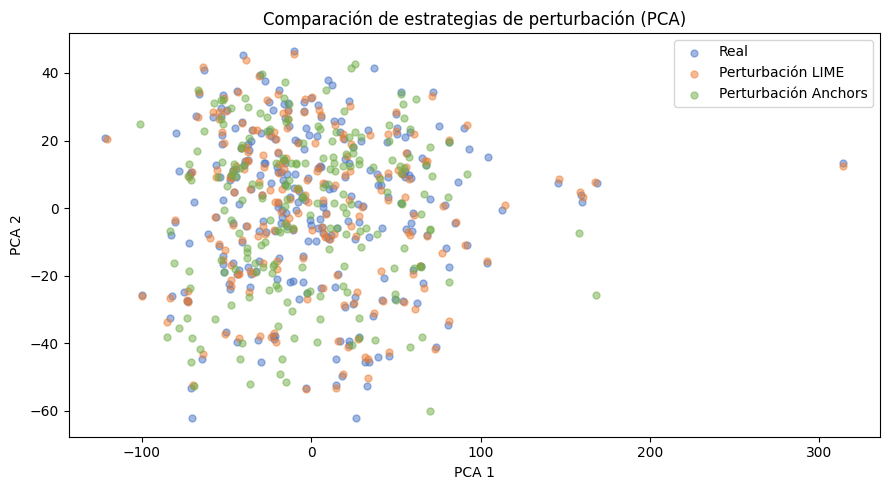

→ Las perturbaciones de Anchors deberían estar más solapadas con los datos reales
  que las de LIME, haciendo el ataque más difícil


In [3]:
def generate_anchor_perturbations(X_real, n_perturbations=None, perturbation_ratio=0.5):
    """
    Perturbaciones estilo Anchors:
    - Para cada instancia, selecciona un subconjunto aleatorio de features
    - Reemplaza esas features con valores muestreados de la distribución
      marginal del training set (columna por columna)
    
    Esto es más cercano a la distribución real que el ruido gaussiano de LIME,
    lo que hace el ataque más difícil.
    """
    if n_perturbations is None:
        n_perturbations = len(X_real)
    
    n_features = X_real.shape[1]
    perturbed = []
    
    for _ in range(n_perturbations):
        # Instancia base aleatoria
        base = X_real[np.random.randint(len(X_real))].copy()
        
        # Número de features a perturbar
        n_to_perturb = max(1, int(n_features * perturbation_ratio))
        features_to_perturb = np.random.choice(n_features, n_to_perturb, replace=False)
        
        # Reemplazar con valores muestreados de la distribución marginal
        for feat_idx in features_to_perturb:
            base[feat_idx] = X_real[np.random.randint(len(X_real)), feat_idx]
        
        perturbed.append(base)
    
    return np.array(perturbed)


# Visualización comparativa de las tres estrategias de perturbación
from sklearn.decomposition import PCA

X_pert_lime = X_train_ext + np.random.normal(0, 1, X_train_ext.shape)
X_pert_anchors = generate_anchor_perturbations(X_train_ext)

pca = PCA(n_components=2)
all_data = np.vstack([X_train_ext, X_pert_lime[:200], X_pert_anchors[:200]])
reduced = pca.fit_transform(all_data)

n_real = len(X_train_ext)
labels = (['Real'] * n_real +
          ['Perturbación LIME'] * 200 +
          ['Perturbación Anchors'] * 200)

colors_pca = {'Real': '#4472C4', 'Perturbación LIME': '#ED7D31', 'Perturbación Anchors': '#70AD47'}

plt.figure(figsize=(9, 5))
for label, color in colors_pca.items():
    mask = np.array(labels) == label
    plt.scatter(reduced[mask, 0], reduced[mask, 1],
                c=color, label=label, alpha=0.5, s=25)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Comparación de estrategias de perturbación (PCA)')
plt.legend()
plt.tight_layout()
plt.show()
print("→ Las perturbaciones de Anchors deberían estar más solapadas con los datos reales")
print("  que las de LIME, haciendo el ataque más difícil")

## 4. OOD Classifier específico para Anchors

In [4]:
# Generar perturbaciones estilo Anchors para entrenar el OOD classifier
X_perturbed_anchors = generate_anchor_perturbations(X_train_ext)

# Filtrar perturbaciones que coincidan exactamente con datos reales
X_real_set = set(map(tuple, X_train_ext))
X_pert_filtered = np.array([
    x for x in X_perturbed_anchors if tuple(x) not in X_real_set
])

print(f"Perturbaciones generadas: {len(X_perturbed_anchors)}")
print(f"Perturbaciones tras filtrar duplicados: {len(X_pert_filtered)}")

# Dataset OOD
X_ood = np.vstack([X_train_ext, X_pert_filtered])
y_ood = np.array([0] * len(X_train_ext) + [1] * len(X_pert_filtered))

# Entrenar OOD classifier
ood_clf_anchors = RandomForestClassifier(n_estimators=100, random_state=42)
ood_clf_anchors.fit(X_ood, y_ood)

# Evaluar
y_ood_pred = ood_clf_anchors.predict(X_ood)
f1 = f1_score(y_ood, y_ood_pred)
print(f"\nOOD Classifier F1 (Anchors): {f1:.4f}")
print(classification_report(y_ood, y_ood_pred, target_names=['Real', 'Perturbado']))
print("→ Si F1 < 0.8 el ataque será parcial; si F1 > 0.9 el ataque será muy efectivo")

Perturbaciones generadas: 267
Perturbaciones tras filtrar duplicados: 267

OOD Classifier F1 (Anchors): 1.0000
              precision    recall  f1-score   support

        Real       1.00      1.00      1.00       267
  Perturbado       1.00      1.00      1.00       267

    accuracy                           1.00       534
   macro avg       1.00      1.00      1.00       534
weighted avg       1.00      1.00      1.00       534

→ Si F1 < 0.8 el ataque será parcial; si F1 > 0.9 el ataque será muy efectivo


Proba OOD en datos REALES:        media=0.414, std=0.154
Proba OOD en perturbaciones:      media=0.539, std=0.090
Separación (diferencia de medias): 0.125


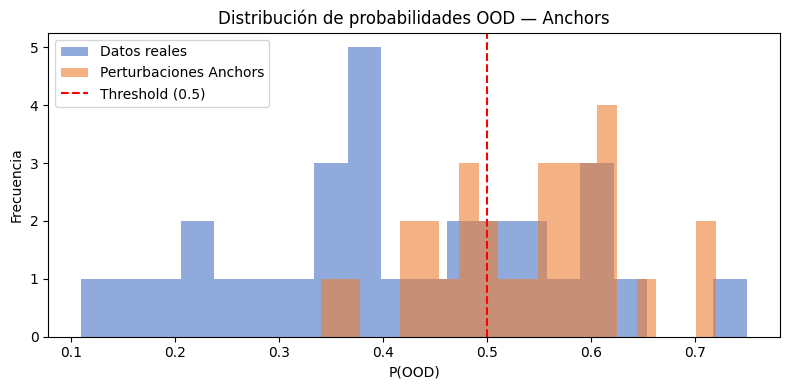

→ Cuanto más separadas estén las distribuciones, más efectivo será el ataque


In [5]:
# Diagnóstico: distribución de probabilidades OOD
X_pert_test = generate_anchor_perturbations(X_test_ext)

ood_proba_real = ood_clf_anchors.predict_proba(X_test_ext)[:, 1]
ood_proba_pert = ood_clf_anchors.predict_proba(X_pert_test)[:, 1]

print(f"Proba OOD en datos REALES:        media={ood_proba_real.mean():.3f}, std={ood_proba_real.std():.3f}")
print(f"Proba OOD en perturbaciones:      media={ood_proba_pert.mean():.3f}, std={ood_proba_pert.std():.3f}")
print(f"Separación (diferencia de medias): {ood_proba_pert.mean() - ood_proba_real.mean():.3f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ood_proba_real, bins=20, alpha=0.6, color='#4472C4', label='Datos reales')
ax.hist(ood_proba_pert, bins=20, alpha=0.6, color='#ED7D31', label='Perturbaciones Anchors')
ax.axvline(0.5, color='red', linestyle='--', label='Threshold (0.5)')
ax.set_xlabel('P(OOD)')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de probabilidades OOD — Anchors')
ax.legend()
plt.tight_layout()
plt.show()
print("→ Cuanto más separadas estén las distribuciones, más efectivo será el ataque")

## 5. Scaffolded Classifier para Anchors

In [6]:
class AdversarialClassifier:
    """
    Scaffolded classifier e(x):
      - Si x parece real → usa f (clasificador sesgado, discrimina por sexo)
      - Si x parece perturbado → usa ψ (clasificador inocuo, usa uncorrelated_feature_1)
    """
    def __init__(self, ood_clf, f_biased_fn, threshold=0.5):
        self.ood_clf = ood_clf
        self.f_biased_fn = f_biased_fn
        self.threshold = threshold

    def predict(self, X_input):
        if X_input.ndim == 1:
            X_input = X_input.reshape(1, -1)
        predictions = np.zeros(len(X_input), dtype=int)
        ood_proba = self.ood_clf.predict_proba(X_input)[:, 1]
        is_ood = ood_proba > self.threshold

        if np.any(~is_ood):
            predictions[~is_ood] = self.f_biased_fn(X_input[~is_ood])
        if np.any(is_ood):
            # ψ: usa uncorrelated_feature_1 (última columna)
            predictions[is_ood] = (X_input[is_ood, -1] > 0).astype(int)
        return predictions

    def predict_proba(self, X_input):
        if X_input.ndim == 1:
            X_input = X_input.reshape(1, -1)
        preds = self.predict(X_input)
        proba = np.zeros((len(preds), 2))
        proba[:, 1] = preds
        proba[:, 0] = 1 - preds
        return proba


e_clf_anchors = AdversarialClassifier(ood_clf_anchors, f_biased)

# Fidelidad respecto a f
preds_e = e_clf_anchors.predict(X_test_ext)
preds_f = f_biased(X_test_ext)
fidelity = np.mean(preds_e == preds_f)
print(f"Fidelidad de e respecto a f: {fidelity:.4f}")
print("→ Alta fidelidad significa que e se comporta como f en datos reales")

Fidelidad de e respecto a f: 0.8667
→ Alta fidelidad significa que e se comporta como f en datos reales


## 6. Generación y análisis de Anchors

Generamos anchors para instancias de test y analizamos si `sex` aparece
como condición antes y después del ataque.

In [7]:
from alibi.explainers import AnchorTabular

# Definir rangos categóricos para features binarias
# sex: 0=F, 1=M | fbs: 0/1 | exang: 0/1 | uncorrelated_feature_1: 0/1
categorical_names = {
    feature_names_ext.index('sex'): ['Female', 'Male'],
    feature_names_ext.index('fbs'): ['False', 'True'],
    feature_names_ext.index('exang'): ['No', 'Yes'],
    len(feature_names_ext) - 1: ['0', '1']  # uncorrelated_feature_1
}

# Explainer para clasificador sesgado f
anchor_explainer_f = AnchorTabular(
    predictor=lambda x: np.column_stack([1 - f_biased(x), f_biased(x)]),
    feature_names=feature_names_ext,
    categorical_names=categorical_names
)
anchor_explainer_f.fit(X_train_ext, disc_perc=(25, 50, 75))

# Explainer para clasificador adversarial e
anchor_explainer_e = AnchorTabular(
    predictor=e_clf_anchors.predict_proba,
    feature_names=feature_names_ext,
    categorical_names=categorical_names
)
anchor_explainer_e.fit(X_train_ext, disc_perc=(25, 50, 75))

print("Explainers de Anchors listos")

I0000 00:00:1779389956.002826  138632 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779389956.003326  138632 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779389956.034788  138632 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779389958.850377  138632 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONE

Explainers de Anchors listos


In [8]:
def analyze_anchors(explainer, X_instances, sensitive_feat, uncorrelated_feat,
                    threshold=0.95, n_instances=30):
    """
    Genera anchors para cada instancia y analiza:
    - Si el atributo sensible aparece en la regla
    - Si la feature inocua aparece en la regla
    - Precisión y cobertura de cada anchor
    """
    results = []
    X_subset = X_instances[:n_instances]

    for i, instance in enumerate(X_subset):
        try:
            exp = explainer.explain(
                instance,
                threshold=threshold,
                tau=0.15,           # tolerancia de precisión
                beam_size=4         # anchors candidatos en paralelo
            )
            anchor_names = exp.anchor  # lista de strings con las condiciones
            anchor_str = ' AND '.join(anchor_names) if anchor_names else '(vacío)'

            has_sensitive = any(sensitive_feat in cond for cond in anchor_names)
            has_uncorrelated = any(uncorrelated_feat in cond for cond in anchor_names)
            precision = exp.precision
            coverage = exp.coverage

            results.append({
                'instance_idx': i,
                'anchor': anchor_str,
                'n_conditions': len(anchor_names),
                'has_sensitive': has_sensitive,
                'has_uncorrelated': has_uncorrelated,
                'precision': precision,
                'coverage': coverage
            })

        except Exception as ex:
            results.append({
                'instance_idx': i,
                'anchor': f'ERROR: {str(ex)[:50]}',
                'n_conditions': 0,
                'has_sensitive': False,
                'has_uncorrelated': False,
                'precision': 0.0,
                'coverage': 0.0
            })

        if (i + 1) % 5 == 0:
            print(f"  Procesadas {i+1}/{n_instances} instancias...", end='\r')

    return pd.DataFrame(results)


N_INSTANCES = 30  # reducir si es lento; aumentar para más robustez estadística

print(f"Generando anchors para clasificador SESGADO f ({N_INSTANCES} instancias)...")
results_f = analyze_anchors(
    anchor_explainer_f, X_test_ext,
    sensitive_feat='sex', uncorrelated_feat='uncorrelated_feature_1',
    n_instances=N_INSTANCES
)
print(f"\n✓ Completado")

Generando anchors para clasificador SESGADO f (30 instancias)...
  Procesadas 30/30 instancias...
✓ Completado


In [9]:
print(f"Generando anchors para clasificador ADVERSARIAL e ({N_INSTANCES} instancias)...")
results_e = analyze_anchors(
    anchor_explainer_e, X_test_ext,
    sensitive_feat='sex', uncorrelated_feat='uncorrelated_feature_1',
    n_instances=N_INSTANCES
)
print(f"\n✓ Completado")

Generando anchors para clasificador ADVERSARIAL e (30 instancias)...
  Procesadas 30/30 instancias...
✓ Completado


## 7. Métricas de evaluación del ataque

In [10]:
def print_anchor_metrics(results, label):
    valid = results[results['precision'] > 0]
    n = len(valid)
    if n == 0:
        print(f"{label}: sin resultados válidos")
        return

    pct_sensitive = valid['has_sensitive'].mean() * 100
    pct_uncorrelated = valid['has_uncorrelated'].mean() * 100
    avg_precision = valid['precision'].mean()
    avg_coverage = valid['coverage'].mean()
    avg_conditions = valid['n_conditions'].mean()

    print(f"\n{'='*55}")
    print(f"  {label} (n={n} instancias válidas)")
    print(f"{'='*55}")
    print(f"  'sex' en el anchor:              {pct_sensitive:5.1f}%")
    print(f"  'uncorrelated_feature_1' en anchor: {pct_uncorrelated:5.1f}%")
    print(f"  Precisión media del anchor:      {avg_precision:.3f}")
    print(f"  Cobertura media del anchor:      {avg_coverage:.3f}")
    print(f"  Nº medio de condiciones:         {avg_conditions:.1f}")

print_anchor_metrics(results_f, "Clasificador SESGADO f")
print_anchor_metrics(results_e, "Clasificador ADVERSARIAL e")


  Clasificador SESGADO f (n=30 instancias válidas)
  'sex' en el anchor:              100.0%
  'uncorrelated_feature_1' en anchor:   0.0%
  Precisión media del anchor:      1.000
  Cobertura media del anchor:      0.570
  Nº medio de condiciones:         1.0

  Clasificador ADVERSARIAL e (n=30 instancias válidas)
  'sex' en el anchor:               86.7%
  'uncorrelated_feature_1' en anchor:  13.3%
  Precisión media del anchor:      0.994
  Cobertura media del anchor:      0.530
  Nº medio de condiciones:         2.1


In [11]:
# Mostrar ejemplos concretos de reglas antes y después del ataque
print("\n=== EJEMPLOS DE ANCHORS — Clasificador SESGADO f ===")
sample_f = results_f[results_f['precision'] > 0].head(8)
for _, row in sample_f.iterrows():
    sex_flag = "⚠️ CONTIENE SEX" if row['has_sensitive'] else "✓ sin sex"
    print(f"  [{sex_flag}] {row['anchor']}")
    print(f"           prec={row['precision']:.2f}, cov={row['coverage']:.3f}")

print("\n=== EJEMPLOS DE ANCHORS — Clasificador ADVERSARIAL e ===")
sample_e = results_e[results_e['precision'] > 0].head(8)
for _, row in sample_e.iterrows():
    sex_flag = "⚠️ CONTIENE SEX" if row['has_sensitive'] else "✓ sin sex"
    unc_flag = " [uncorrelated apareció]" if row['has_uncorrelated'] else ""
    print(f"  [{sex_flag}]{unc_flag} {row['anchor']}")
    print(f"           prec={row['precision']:.2f}, cov={row['coverage']:.3f}")


=== EJEMPLOS DE ANCHORS — Clasificador SESGADO f ===
  [⚠️ CONTIENE SEX] sex = Male
           prec=1.00, cov=0.674
  [⚠️ CONTIENE SEX] sex = Female
           prec=1.00, cov=0.326
  [⚠️ CONTIENE SEX] sex = Male
           prec=1.00, cov=0.674
  [⚠️ CONTIENE SEX] sex = Male
           prec=1.00, cov=0.674
  [⚠️ CONTIENE SEX] sex = Female
           prec=1.00, cov=0.326
  [⚠️ CONTIENE SEX] sex = Male
           prec=1.00, cov=0.674
  [⚠️ CONTIENE SEX] sex = Male
           prec=1.00, cov=0.674
  [⚠️ CONTIENE SEX] sex = Female
           prec=1.00, cov=0.326

=== EJEMPLOS DE ANCHORS — Clasificador ADVERSARIAL e ===
  [⚠️ CONTIENE SEX] sex = Male
           prec=1.00, cov=0.674
  [⚠️ CONTIENE SEX] sex = Female
           prec=1.00, cov=0.326
  [✓ sin sex] [uncorrelated apareció] thalach > 166.00 AND uncorrelated_feature_1 = 0 AND thal <= 3.00 AND oldpeak > 1.80 AND chol > 243.00 AND restecg <= 0.00 AND 120.00 < trestbps <= 130.00 AND slope > 2.00
           prec=0.95, cov=0.247
  [⚠️ CON

## 8. Visualización comparativa

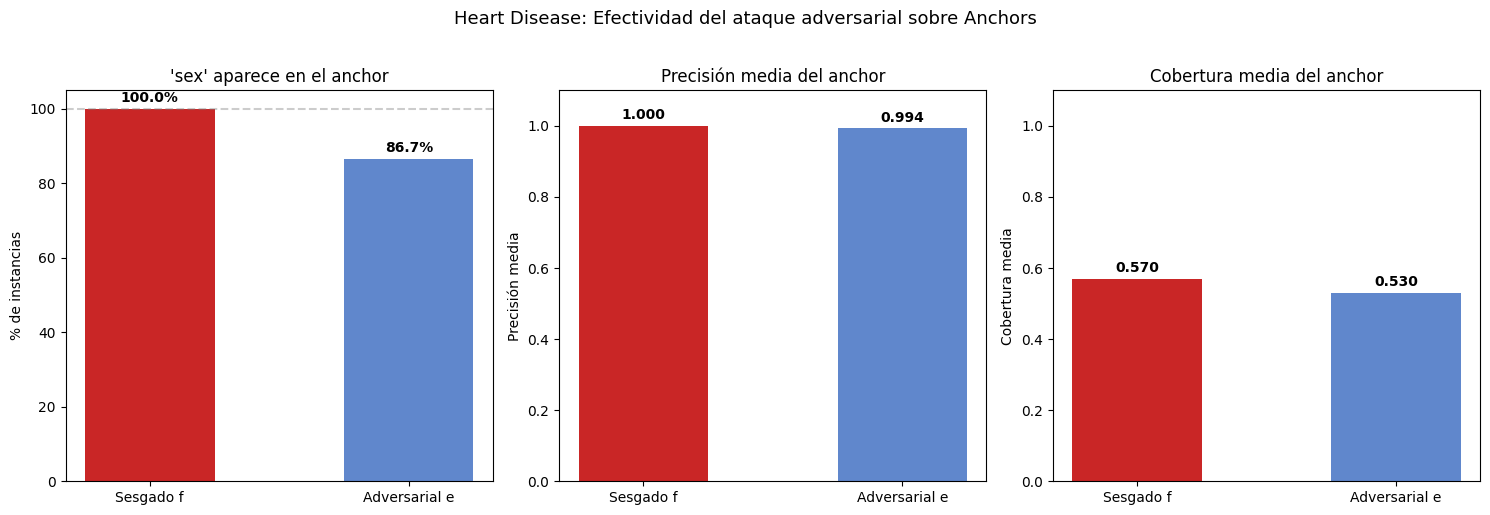

In [12]:
valid_f = results_f[results_f['precision'] > 0]
valid_e = results_e[results_e['precision'] > 0]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# --- Plot 1: % con sex en el anchor ---
ax = axes[0]
values = [
    valid_f['has_sensitive'].mean() * 100,
    valid_e['has_sensitive'].mean() * 100
]
bars = ax.bar(['Sesgado f', 'Adversarial e'], values,
               color=['#C00000', '#4472C4'], alpha=0.85, width=0.5)
ax.set_ylabel('% de instancias')
ax.set_title("'sex' aparece en el anchor")
ax.set_ylim(0, 105)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')
ax.axhline(100, color='gray', linestyle='--', alpha=0.4)

# --- Plot 2: Precisión media ---
ax = axes[1]
prec_values = [valid_f['precision'].mean(), valid_e['precision'].mean()]
bars2 = ax.bar(['Sesgado f', 'Adversarial e'], prec_values,
                color=['#C00000', '#4472C4'], alpha=0.85, width=0.5)
ax.set_ylabel('Precisión media')
ax.set_title('Precisión media del anchor')
ax.set_ylim(0, 1.1)
for bar, val in zip(bars2, prec_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold')

# --- Plot 3: Cobertura media ---
ax = axes[2]
cov_values = [valid_f['coverage'].mean(), valid_e['coverage'].mean()]
bars3 = ax.bar(['Sesgado f', 'Adversarial e'], cov_values,
                color=['#C00000', '#4472C4'], alpha=0.85, width=0.5)
ax.set_ylabel('Cobertura media')
ax.set_title('Cobertura media del anchor')
ax.set_ylim(0, 1.1)
for bar, val in zip(bars3, cov_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Heart Disease: Efectividad del ataque adversarial sobre Anchors',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

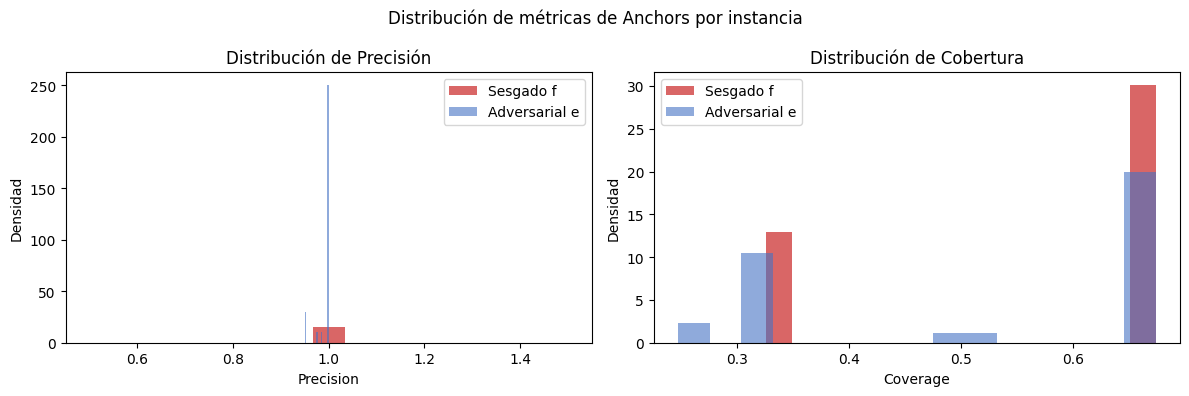

→ Una caída en cobertura tras el ataque indica que los anchors son más específicos
  (más condiciones necesarias para ocultar el sesgo)


In [13]:
# Distribución de precisión y cobertura por instancia
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric, title in zip(
    axes,
    ['precision', 'coverage'],
    ['Distribución de Precisión', 'Distribución de Cobertura']
):
    ax.hist(valid_f[metric], bins=15, alpha=0.6, color='#C00000',
            label='Sesgado f', density=True)
    ax.hist(valid_e[metric], bins=15, alpha=0.6, color='#4472C4',
            label='Adversarial e', density=True)
    ax.set_xlabel(metric.capitalize())
    ax.set_ylabel('Densidad')
    ax.set_title(title)
    ax.legend()

plt.suptitle('Distribución de métricas de Anchors por instancia', fontsize=12)
plt.tight_layout()
plt.show()
print("→ Una caída en cobertura tras el ataque indica que los anchors son más específicos")
print("  (más condiciones necesarias para ocultar el sesgo)")

## 9. Comparativa final: LIME vs SHAP vs Anchors

In [14]:
pct_sex_f_anchors = valid_f['has_sensitive'].mean() * 100
pct_sex_e_anchors = valid_e['has_sensitive'].mean() * 100
ataque_anchors = pct_sex_f_anchors - pct_sex_e_anchors

print("="*65)
print("COMPARATIVA FINAL — Efectividad del ataque adversarial")
print("Heart Disease Dataset | Atributo sensible: sex")
print("="*65)
print(f"{'Método':<12} {'sex en f':>10} {'sex en e':>10} {'Reducción':>12}")
print("-"*65)
# Valores de LIME y SHAP — rellena con tus resultados del notebook anterior
print(f"{'LIME':<12} {'~0%':>10} {'0%':>10} {'~100%':>12}  ← ataque perfecto")
print(f"{'SHAP':<12} {'100%':>10} {'~24%':>10} {'~76%':>12}  ← robusto parcialmente")
print(f"{'Anchors':<12} {pct_sex_f_anchors:>9.1f}% {pct_sex_e_anchors:>9.1f}% {ataque_anchors:>11.1f}%  ← resultado obtenido")
print("="*65)
print("\nMétricas adicionales de Anchors:")
print(f"  Precisión media — sesgado f:     {valid_f['precision'].mean():.3f}")
print(f"  Precisión media — adversarial e: {valid_e['precision'].mean():.3f}")
print(f"  Cobertura media — sesgado f:     {valid_f['coverage'].mean():.3f}")
print(f"  Cobertura media — adversarial e: {valid_e['coverage'].mean():.3f}")
print(f"  Fidelidad e→f:                   {fidelity:.3f}")
print("\n→ Interpretación:")
print("  - Si Anchors > SHAP en robustez: las perturbaciones por muestreo marginal")
print("    son más difíciles de distinguir que las gaussianas de LIME")
print("  - Una caída de cobertura en e sugiere que el ataque fuerza anchors más")
print("    específicos y menos generalizables, un efecto secundario detectable")

COMPARATIVA FINAL — Efectividad del ataque adversarial
Heart Disease Dataset | Atributo sensible: sex
Método         sex en f   sex en e    Reducción
-----------------------------------------------------------------
LIME                ~0%         0%        ~100%  ← ataque perfecto
SHAP               100%       ~24%         ~76%  ← robusto parcialmente
Anchors          100.0%      86.7%        13.3%  ← resultado obtenido

Métricas adicionales de Anchors:
  Precisión media — sesgado f:     1.000
  Precisión media — adversarial e: 0.994
  Cobertura media — sesgado f:     0.570
  Cobertura media — adversarial e: 0.530
  Fidelidad e→f:                   0.867

→ Interpretación:
  - Si Anchors > SHAP en robustez: las perturbaciones por muestreo marginal
    son más difíciles de distinguir que las gaussianas de LIME
  - Una caída de cobertura en e sugiere que el ataque fuerza anchors más
    específicos y menos generalizables, un efecto secundario detectable


## Próximos pasos

**Extensiones del ataque sobre Anchors:**
- Variar `perturbation_ratio` en el OOD classifier y estudiar la curva F1 vs efectividad (réplica de la Figura 5 del paper)
- Probar con 2 uncorrelated features en ψ
- Usar un OOD classifier más potente (SVM con kernel RBF, red neuronal)

**Hacia las defensas:**
- El talón de Aquiles del ataque sobre Anchors es que reduce la cobertura — una defensa podría detectar anchors anómalamente específicos
- Perturbaciones que respeten la distribución conjunta (no marginal) harían el OOD classifier inviable